In [1]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import gensim
import gensim.corpora as corpora

In [2]:
data = pd.read_csv('news_articles.csv')

In [3]:
data.head()

,id,title,content
0,25626,"One Weight-Loss Approach Fits All? No, Not Eve...","Dr. Frank Sacks, a professor of nutrition at H..."
1,19551,South Carolina Stuns Baylor to Reach the Round...,South Carolina’s win over Duke was not only ...
2,25221,"U.S. Presidential Race, Apple, Gene Wilder: Yo...",(Want to get this briefing by email? Here’s th...
3,18026,"His Predecessor Gone, Gambia’s New President F...","BANJUL, Gambia — A week after he was inaugu..."
4,21063,‘Harry Potter and the Cursed Child’ Goes From ...,The biggest book of the summer isn’t a blockbu...


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       100 non-null    int64
 1   title    100 non-null    str  
 2   content  100 non-null    str  
dtypes: int64(1), str(2)
memory usage: 2.5 KB


In [5]:
articles = data['content']

In [6]:
articles = data['content'].str.lower().apply(lambda s: re.sub(r'[^\s\w]', '', s))

In [7]:
articles.head()

0    dr frank sacks a professor of nutrition at har...
1    south carolinas win over   duke was not only a...
2    want to get this briefing by email heres the  ...
3    banjul gambia     a week after he was inaugura...
4    the biggest book of the summer isnt a blockbus...
Name: content, dtype: str

In [8]:
en_stopwords = stopwords.words('english')
articles = articles.apply(lambda sentence: ' '.join([word for word in sentence.split() if word not in en_stopwords]))

In [9]:
articles = articles.apply(lambda s: word_tokenize(s))

In [10]:
ps = PorterStemmer()
articles = articles.apply(lambda tokens: [ps.stem(token) for token in tokens ])

In [11]:
articles

0     [dr, frank, sack, professor, nutrit, harvard, ...
1     [south, carolina, win, duke, surpris, fan, pos...
2     [want, get, brief, email, here, good, even, he...
3     [banjul, gambia, week, inaugur, anoth, countri...
4     [biggest, book, summer, isnt, blockbust, thril...
                            ...                        
95    [want, get, brief, email, here, good, even, he...
96    [tallinn, estonia, guard, brought, ahm, abdul,...
97    [gov, scott, walker, wisconsin, activ, wiscons...
98    [social, media, shook, emot, headlin, shout, n...
99    [moment, joanna, acevedo, first, set, foot, bo...
Name: content, Length: 100, dtype: object

In [12]:
dictionary = corpora.Dictionary(articles)

In [13]:
print(dictionary)

Dictionary<8693 unique tokens: ['10', '100', '108', '15', '155']...>


In [14]:
doc_term = [dictionary.doc2bow(text) for text in articles]

In [15]:
# print(doc_term)

In [16]:
num_topics = 2

In [17]:
lda_model = gensim.models.LdaModel(corpus=doc_term,
                                  id2word=dictionary,
                                  num_topics=num_topics)

In [18]:
lda_model.print_topics(num_topics=num_topics, num_words=5)

[(0,
  '0.016*"mr" + 0.014*"said" + 0.007*"trump" + 0.005*"would" + 0.005*"year"'),
 (1,
  '0.018*"mr" + 0.015*"said" + 0.005*"one" + 0.004*"trump" + 0.004*"state"')]

In [19]:
from gensim.models import LsiModel

In [20]:
lsa_model = LsiModel(
    corpus=doc_term, id2word=dictionary, num_topics=num_topics
)

In [21]:
print(lsa_model.print_topics(num_topics=num_topics, num_words=5))

[(0, '0.615*"mr" + 0.429*"said" + 0.187*"trump" + 0.130*"state" + 0.119*"would"'), (1, '-0.537*"mr" + -0.319*"trump" + 0.286*"said" + 0.242*"saudi" + 0.142*"weight"')]


## *How many topics*

In [22]:
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

In [23]:
coherence_values = []
model_list = []

In [24]:
min_topics = 2
max_topics = 11

In [25]:
for num_topics_i in range(min_topics, max_topics+1):
    model = LsiModel(corpus=doc_term, id2word=dictionary,  num_topics=num_topics_i)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model, texts=articles, dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherence_model.get_coherence())

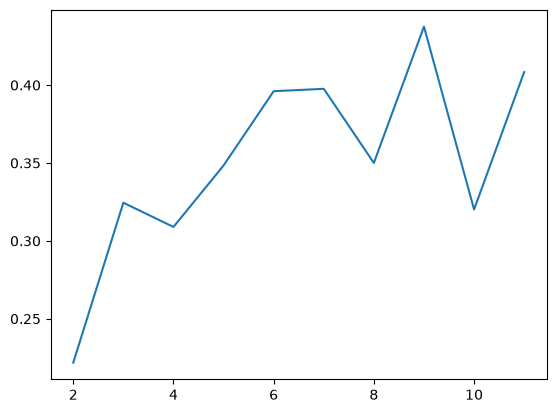

In [26]:
plt.plot(range(min_topics, max_topics+1), coherence_values)

In [27]:
final_num_topics = 3
final_lsa_model = LsiModel(corpus=doc_term, id2word=dictionary, num_topics=final_num_topics)
print(final_lsa_model.print_topics(num_topics=final_num_topics, num_words=10))

[(0, '0.615*"mr" + 0.429*"said" + 0.187*"trump" + 0.130*"state" + 0.119*"would" + 0.108*"year" + 0.102*"one" + 0.091*"like" + 0.090*"peopl" + 0.086*"new"'), (1, '-0.537*"mr" + -0.319*"trump" + 0.286*"said" + 0.242*"saudi" + 0.142*"weight" + 0.140*"taliban" + 0.120*"one" + 0.120*"dr" + 0.120*"peopl" + 0.107*"year"'), (2, '0.460*"saudi" + 0.264*"taliban" + -0.249*"weight" + 0.194*"afghanistan" + -0.191*"dr" + 0.189*"arabia" + 0.174*"afghan" + 0.139*"offici" + -0.139*"diet" + 0.127*"state"')]
